In [1]:
from collections import OrderedDict
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10

import flwr as fl
from flwr.common import Metrics

In [2]:
DEVICE = torch.device("cpu")
print(f"Training on {DEVICE} using PyTorch {torch.__version__} and Flower {fl.__version__}")

Training on cpu using PyTorch 2.10.0+cpu and Flower 1.26.1


In [3]:
CLASSES = (
    "plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck",
)

In [4]:
NUM_CLIENTS = 10

In [5]:
BATCH_SIZE = 32

def load_datasets():
    # Download and transform CIFAR-10(train and test)
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    trainset = CIFAR10("../../datasets", train=True, download=True, transform=transform)
    testset = CIFAR10("../../datasets", train=False, download=True, transform=transform)

    # Split training set into 10 partitions to simulate the individual dataset
    partition_size = len(trainset) // NUM_CLIENTS
    lengths = [partition_size] * NUM_CLIENTS
    datasets = random_split(trainset, lengths, torch.Generator().manual_seed(42))

    # Split each partition into train, validation, and create DataLoader
    trainloaders = []
    valloaders = []

    for ds in datasets:
        len_val = len(ds) // 10 # 10% validation set
        len_train = len(ds) - len_val
        lengths = [len_train, len_val]

        ds_train, ds_val = random_split(ds, lengths, torch.Generator().manual_seed(42))

        trainloaders.append(DataLoader(ds_train, batch_size=BATCH_SIZE,shuffle=True))
        valloaders.append(DataLoader(ds_val, batch_size=BATCH_SIZE))
    
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)

    return trainloaders, valloaders, testloader


In [6]:
trainloaders, valloaders, testloader = load_datasets()

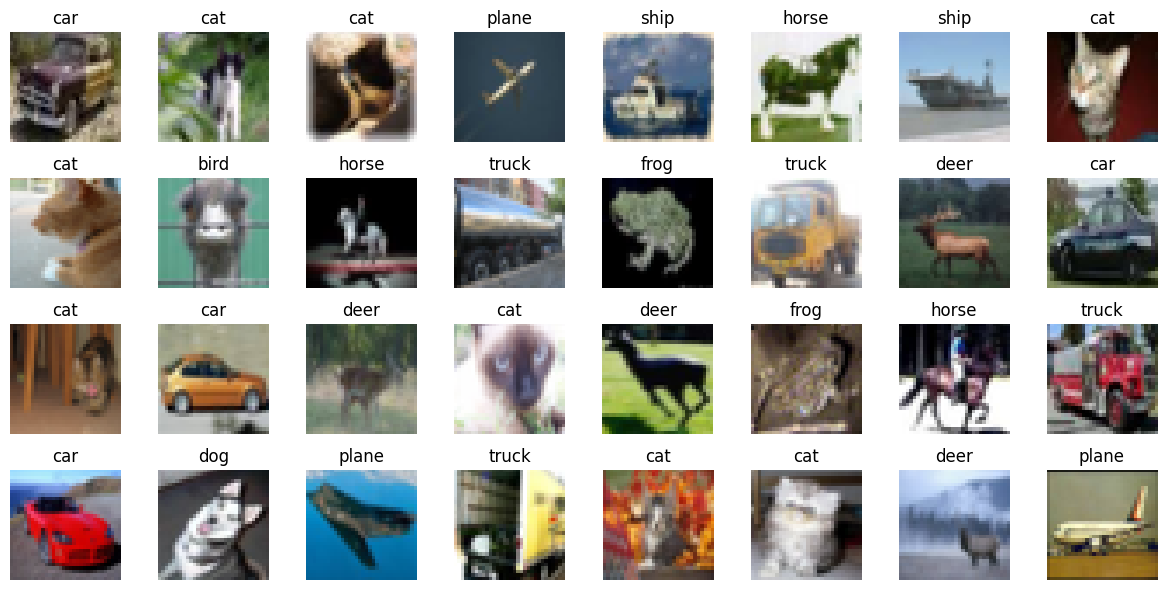

In [7]:
images, labels = next(iter(trainloaders[0]))

# Reshape and convert images to a NumPy array
# Matplotlib requires images with the shape(height, width, 3)
images = images.permute(0, 2, 3, 1).numpy()

# Denormalize
images = images / 2 + 0.5

# create a figure and a grid of subplots
fig, axs = plt.subplots(4, 8, figsize=(12, 6))

# loop over the images and plot them
for i, ax in enumerate(axs.flat):
    ax.imshow(images[i])
    ax.set_title(CLASSES[labels[i]])
    ax.axis('off')

# show the plot
fig.tight_layout()
plt.show()

In [8]:
# model
class Net(nn.Module):
    def __init__(self) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x)) 
        x = self.fc3(x)

        return x 

In [9]:
def train(net, trainloader, epochs: int, verbose=False):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters())
    net.train()

    for epoch in range(epochs):
        correct, total = 0, 0
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            total += labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = correct / total

        if verbose:
            print(f"Epoch {epoch+1}: train loss={epoch_loss:.4f}, acc={epoch_acc:.4f}")


In [10]:
def test(net, testloader):
    """Evaluate the network on the entire test set"""
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    net.eval()

    with torch.no_grad():
         for images, labels in testloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = net(images)
            loss = loss + criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total = total + labels.size(0)
    
    loss = loss / len(testloader.dataset)
    accuracy = correct / total
    return loss, accuracy

In [11]:
trainloader = trainloaders[0]
valloader = valloaders[0]

net = Net().to(DEVICE)

for epoch in range(5):
    train(net, trainloader, 1)
    loss, accuracy = test(net, valloader)
    print(f"Epoch {epoch + 1}: validation loss: {loss}, accuracy: {accuracy}")

loss, accuracy = test(net, testloader)
print(f"Final test set performance:\n\tloss: {loss}\n\taccuracy:{accuracy}")


Epoch 1: validation loss: 0.06186828708648682, accuracy: 0.0
Epoch 2: validation loss: 0.057538079261779784, accuracy: 0.0
Epoch 3: validation loss: 0.053097285270690915, accuracy: 0.0
Epoch 4: validation loss: 0.05244140625, accuracy: 0.0
Epoch 5: validation loss: 0.05261690092086792, accuracy: 0.0
Final test set performance:
	loss: 0.04914599168300628
	accuracy:0.0


# Federated Learning with Flower

We need two helper functions to update the local model with parameters received from the server and to get the updated model parameters from the local model: set_parameters and get_parameters.

In [12]:
def get_parameters(net) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in net.state_dict().items()]

In [13]:
def set_parameters(net, parameters: List[np.ndarray]):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)

## Implementing a Flower client
 Federated learning systems consist of a server and multiple clients. In Flower, we create clients by implementing subclasses of flwr.client.Client or flwr.client.NumPyClient.

 To implement the Flower client, we create a subclass of flwr.client.NumPyClient and implement the three methods get_parameters, fit, and evaluate:

* get_parameters: Return the current local model parameters
* fit: Receive model parameters from the server, train the model parameters on the local data, and return the (updated) model parameters to the server
* evaluate: Receive model parameters from the server, evaluate the model parameters on the local data, and return the evaluation result to the server

In [14]:
class FLowerClient(fl.client.NumPyClient):
    def __init__(self, net, trainloader, valloader):
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader
    
    def get_parameters(self, config):
        return get_parameters(self.net)
    
    def fit(self, parameters, config):
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=1)
        return get_parameters(self.net), len(self.trainloader), {}
    
    def evaluate(self, parameters, config):
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return (loss), len(self.valloader), {"accuracy": float(accuracy)}


Using the Virtual Client Engine
In this notebook, we want to simulate a federated learning system with 10 clients on a single machine. This means that the server and all 10 clients will live on a single machine and share resources such as CPU, GPU, and memory. Having 10 clients would mean having 10 instances of FlowerClient in memory. Doing this on a single machine can quickly exhaust the available memory resources, even if only a subset of these clients participates in a single round of federated learning.

In addition to the regular capabilities where server and clients run on multiple machines, Flower, therefore, provides special simulation capabilities that create FlowerClient instances only when they are actually necessary for training or evaluation. To enable the Flower framework to create clients when necessary, we need to implement a function called client_fn that creates a FlowerClient instance on demand. Flower calls client_fn whenever it needs an instance of one particular client to call fit or evaluate (those instances are usually discarded after use, so they should not keep any local state). Clients are identified by a client ID, or short cid. The cid can be used, for example, to load different local data partitions for different clients.

In [15]:
def client_fn(cid: str) -> FLowerClient:
    """ Create a Flower client representing a single organization """
    
    # load Model
    net = Net().to(DEVICE)

    # Load data
    # Note: each client gets a different trainloader/valloader, so each client will train and evaluate on their own unique data

    trainloader = trainloaders[int(cid)]
    valloader = valloaders[int(cid)]

    # create a single flower client representing a single organization
    return FLowerClient(net, trainloader, valloader)

In [16]:
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples,m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # aggregate and return custom metric(weighed average)
    return {"accuracy": sum(accuracies) / sum(examples)}

## Starting the training
 The last step is to start the actual simulation using flwr.simulation.start_simulation.

 The function start_simulation accepts a number of arguments, amongst them the client_fn used to create FlowerClient instances, the number of clients to simulate (num_clients), the number of federated learning rounds (num_rounds), and the strategy. The strategy encapsulates the federated learning approach/algorithm, for example, Federated Averaging (FedAvg).

In [17]:
# create Fedavg strategy
strategy = fl.server.strategy.FedAvg(
    fraction_fit = 1.0, # sample 100% of available clients for training
    fraction_evaluate = 0.5, # sample 50% of available clients for evaluation
    min_fit_clients = 10, # never sample less than 10 clients for training 
    min_evaluate_clients = 5, # never sample less than 5 clients for evaluation
    min_available_clients = 10, # wait untill all 10 clients are available
    evaluate_metrics_aggregation_fn = weighted_average,
)

# specify client resource if you need GPU (defaults to 1 CPU and 0 GPU)
client_resources = None
if DEVICE.type == "cuda":
    client_resources = {"num_cpus": 2, "num_gpus": 1}

# start simulation
fl.simulation.start_simulation(
    client_fn = client_fn,
    num_clients = NUM_CLIENTS,
    config = fl.server.ServerConfig(num_rounds=5),
    strategy = strategy,
    client_resources = client_resources,
)

2026-02-19 17:40:19,799	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-02-19 17:40:22,170	INFO worker.py:2012 -- Started a local Ray instance.
c:\Users\trt\Desktop\research_pyt\venv\lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off thi

History (loss, distributed):
	round 1: 0.06348248505592347
	round 2: 0.05636690111160279
	round 3: 0.05301807951927186
	round 4: 0.050527181863784784
	round 5: 0.04912632250785827
History (metrics, distributed, evaluate):
{'accuracy': [(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0)]}

# Behind the scenes
So how does this work? How does Flower execute this simulation?When we call start_simulation, we tell Flower that there are 10 clients (num_clients=10). Flower then goes ahead an asks the FedAvg strategy to select clients. FedAvg knows that it should select 100% of the available clients (fraction_fit=1.0), so it goes ahead and selects 10 random clients (i.e., 100% of 10).

Flower then asks the selected 10 clients to train the model. When the server receives the model parameter updates from the clients, it hands those updates over to the strategy (FedAvg) for aggregation. The strategy aggregates those updates and returns the new global model, which then gets used in the next round of federated learning.